In [1]:
import pandas as pd
import numpy as np
import json
import yfinance as yf
import matplotlib.pyplot as plt

This code converts ESV DATA given into a dataframe for data analysis

In [2]:
with open("ESV DATA.txt", "r") as file:
    raw_text = file.read()
data = json.loads(raw_text)
all_records = []
for stock_symbol, stock_data in data.items():
    for entry in stock_data.get("DATA", []):
        flat_entry = {}
        flat_entry['STOCK'] = stock_symbol
        flat_entry['DateTime'] = entry.get('DateTime', {}).get('$date', None)
        for timeframe in ['5m', '15m', 'D', 'H', 'M', 'W']:
            if timeframe in entry:
                for k, v in entry[timeframe].items():
                    flat_entry[f"{timeframe}.{k}"] = v

        all_records.append(flat_entry)
df_ESV = pd.DataFrame(all_records)
df_ESV['DateTime'] = pd.to_datetime(df_ESV['DateTime'], errors='coerce')
df_ESV['DateTime'] = pd.to_datetime(df_ESV['DateTime']).dt.date

This code converts HOVER DATA given into a dataframe for data analysis

In [3]:
with open("HOVER DATA.txt", "r") as file:
    raw_text = file.read()
data = json.loads(raw_text)

# Manual flattening
all_records = []
for stock_symbol, stock_data in data.items():
    for entry in stock_data.get("DATA", []):
        flat_entry = {}

        # Basic info
        flat_entry['STOCK'] = stock_symbol

        # DateTime extraction
        flat_entry['DateTime'] = entry.get('DateTime', {}).get('$date', None)

        # Flatten each timeframe: 5m, 15m, D, H, M, W
        for timeframe in ['5m', '15m', 'D', 'H', 'M', 'W']:
            if timeframe in entry:
                for k, v in entry[timeframe].items():
                    flat_entry[f"{timeframe}.{k}"] = v

        all_records.append(flat_entry)

# Final DataFrame
df_HOVER = pd.DataFrame(all_records)

# Parse DateTime
df_HOVER['DateTime'] = pd.to_datetime(df_HOVER['DateTime'], errors='coerce')
df_HOVER['DateTime'] = pd.to_datetime(df_HOVER['DateTime']).dt.date

The dataframes were merged and the columns having Nan values were removed.

In [4]:
merged_df_H = pd.merge(df_HOVER, df_ESV, on=['STOCK', 'DateTime'], how='inner')
df = merged_df_H.replace(r'^\s*$', np.nan, regex=True)
df = df.dropna(axis=1, how='any')
df = df[[col for col in df.columns if not col.startswith(('5m.', '15m.'))]]
df = df.sort_values(by=['DateTime', 'STOCK'])
df = df.rename(columns={'DateTime': 'Date'})
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d').dt.strftime('%Y-%m-%d')
df

,STOCK,Date,D.perc_chg_x,D.MP20,D.MP50,D.MP200,D.MCo,D.RSI,D.MACD,D.per_volume_change_x,...,W.PDSMA200,W.EMA20D50,W.EMA20D200,W.EMA50D200,W.RISING_RSI,W.RISING_LTP,W.DECLINING_RSI,W.DECLINING_LTP,W.RISING_VOLUME,W.DECLINING_VOLUME
62512,3MINDIA,2023-02-08,0.95,DPA20,DPA50,DPA200,DBUCO,55.96,ABV BUCO,1211.28,...,3.73,0.35,2.51,2.17,True,True,False,False,True,False
55180,AARTIDRUGS,2023-02-08,0.23,DPB20,DPB50,DPB200,DBECO,32.73,BLW BECO,-48.27,...,-11.6,-5.05,0.03,4.84,False,False,False,False,False,False
55302,AAVAS,2023-02-08,1.68,DPA20,DPA50,DPB200,DBUCO,61.33,ABV BUCO,-52.45,...,1.46,-7.38,-0.12,6.76,False,False,False,False,False,False
54578,ABB,2023-02-08,1.85,DPA20,DPA50,DPA200,DBECO,66.92,ABV BUCO,10.23,...,43.49,6.85,40.17,35.77,True,True,False,False,False,False
62632,ABBOTINDIA,2023-02-08,1.37,DPB20,DPA50,DPA200,DBUCO,50.03,BLW BECO,2.81,...,25.12,5.19,22.5,18.26,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52216,ZENSARTECH,2023-08-31,6.05,DPA20,DPA50,DPA200,DBUCO,65.48,ABV BECO,374.63,...,47.29,16.45,34.34,21.42,True,True,False,False,False,False
51952,ZFCVINDIA,2023-08-31,5.44,DPA20,DPA50,DPA200,DBUCO,66.71,ABV BECO,31.09,...,43.41,10.58,35.02,27.33,False,False,False,False,False,False
52348,ZOMATO,2023-08-31,-2.2,DPA20,DPA50,DPA200,DBUCO,64.24,ABV BUCO,-54.82,...,nan,8.42,nan,nan,True,True,False,False,True,False
52477,ZYDUSLIFE,2023-08-31,-0.36,DPB20,DPA50,DPA200,DBUCO,45.59,ABV BECO,79.47,...,30.51,11.05,25.06,15.76,False,False,True,True,False,True


A dataframe has been made containing the top filtered stocks on a daily basis according to the threshold already specified. According to the capital allocation to each stock, the final returns are calculated daily


In [5]:
def num_stocks_to_buy(capital):
    if 500 < capital <= 50000:
        return 3
    elif 50000 < capital <= 1000000:
        return 4
    else:
        return 5

def allocation_per_stock(capital, n_stocks):
    return capital / n_stocks
initial_capital = 100000  
capital = initial_capital

all_dates = df['Date'].unique()

results = pd.DataFrame(index=all_dates, columns=[f'Stock_{i+1}' for i in range(5)])
returns_df = pd.DataFrame(index=all_dates, columns=[f'Return_{i+1}' for i in range(5)])
daily_percent_profit = []
portfolio_values = []
#Filtering 
for current_date in all_dates:
    day_df = df[df['Date'] == current_date].copy()
    day_df['D.RSI'] = pd.to_numeric(day_df['D.RSI'], errors='coerce')
    day_df['M.RSI'] = pd.to_numeric(day_df['M.RSI'], errors='coerce')
    day_df['W.RSI'] = pd.to_numeric(day_df['W.RSI'], errors='coerce')
    filtered = day_df[
        (day_df['D.MP200'] == 'DPA200') &
        (day_df['D.MP50'] == 'DPA50') &
        (day_df['D.RSI'] > 60) & (day_df['D.RSI'] < 85) &
        (day_df['M.RSI'] > 40) &
        (day_df['W.RSI'] > 40) &
        (day_df['H.MP50'] == 'HPA50') &
        (day_df['H.MCo'] == 'HBUCO') 
    ]

    # Sort
    filtered = filtered.sort_values(by=['D.PDEMA20', 'D.RSI'], ascending=[False, False])
    n = num_stocks_to_buy(capital)
    top_stocks = filtered.head(n)
    stock_names = list(top_stocks['STOCK']) + [np.nan] * (5 - len(top_stocks))
    results.loc[current_date] = stock_names[:5]
    stock_returns = list(top_stocks['D.perc_chg_x'])+[0.0]*(5-len(top_stocks))
    returns_df.loc[current_date] = stock_returns[:5]
    alloc = allocation_per_stock(capital, max(len(top_stocks), 1)) 
    stock_returns = [float(r) for r in stock_returns] 
    profits = [(alloc * (r / 100)) for r in stock_returns[:n]]  
    total_profit = sum(profits)
    total_percent = (total_profit / capital) * 100
    capital += total_profit
    daily_percent_profit.append(total_percent)
    portfolio_values.append(capital)
final_output = pd.concat([results, returns_df], axis=1)
final_output['Daily % Profit'] = daily_percent_profit
final_output['Portfolio Value'] = portfolio_values
final_output

,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5,Return_1,Return_2,Return_3,Return_4,Return_5,Daily % Profit,Portfolio Value
2023-02-08,PGHL,ZENSARTECH,FSL,KPITTECH,NaN,-0.61,2.83,1.69,3.13,0.0,1.7600,1.017600e+05
2023-02-09,M&MFIN,ELGIEQUIP,ZENSARTECH,KPITTECH,NaN,0.48,3.34,0.42,1.75,0.0,1.4975,1.032839e+05
2023-02-10,ELGIEQUIP,CUMMINSIND,PGHL,FSL,NaN,0.8,1.42,0.58,1.04,0.0,0.9600,1.042754e+05
2023-02-13,CGPOWER,CERA,ELGIEQUIP,CUMMINSIND,NaN,2.01,1.17,-0.38,-0.35,0.0,0.6125,1.049141e+05
2023-02-14,ELGIEQUIP,KPITTECH,CGPOWER,ZENSARTECH,NaN,3.17,1.73,0.39,2.25,0.0,1.8850,1.068917e+05
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-24,ESCORTS,RTNINDIA,BLS,MMTC,BEML,3.02,4.3,1.5,-2.41,1.19,1.5200,1.228718e+06
2023-08-25,COCHINSHIP,SUPREMEIND,VARROC,SUNTV,APLAPOLLO,-1.07,1.48,-0.8,6.34,2.36,1.6620,1.249140e+06
2023-08-28,ESCORTS,RECLTD,CERA,MMTC,TMB,-0.63,1.65,-0.02,3.25,1.9,1.2300,1.264504e+06
2023-08-29,CHEMPLASTS,KALYANKJIL,KALYANKJIL,VARROC,VARROC,-0.27,3.29,3.29,0.35,0.35,1.4020,1.282232e+06


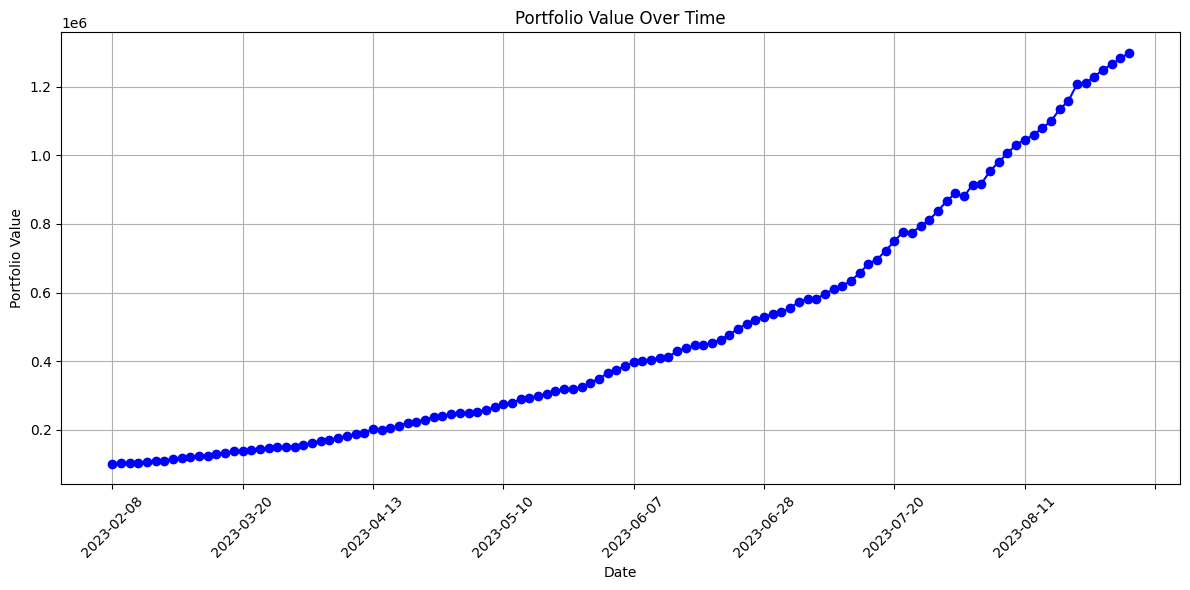

In [6]:
final_portfolio_value= final_output['Portfolio Value'].iloc[-1]
final_portfolio_value
#plot
plt.figure(figsize=(12, 6))
plt.plot(final_output['Portfolio Value'], marker='o', linestyle='-', color='b')
plt.title('Portfolio Value Over Time')
plt.xlabel('Date')
plt.ylabel('Portfolio Value')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(nbins=10))
plt.grid()
plt.tight_layout()
plt.show()

In [7]:
nifty=pd.read_csv('NIFTY_50.csv')
nifty.columns = nifty.columns.str.strip()
nifty['Date'] = pd.to_datetime(nifty['Date'], format='%d-%b-%Y').dt.strftime('%Y-%m-%d').reset_index(drop=True)
nifty['NIFTY_Returns'] = nifty['Close'].pct_change()*100
nifty.set_index('Date', inplace=True)

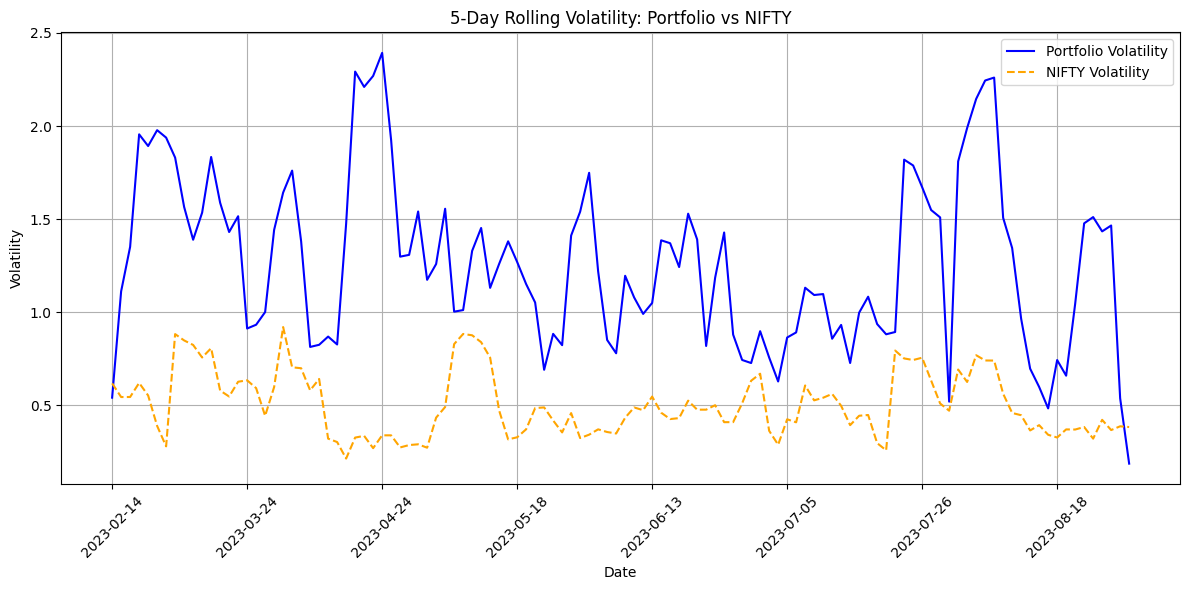

In [8]:
merged_df = final_output.merge(nifty, left_index=True, right_index=True, how='inner')
vol_df = merged_df[['Daily % Profit', 'NIFTY_Returns']].rolling(window=5).std()
vol_df = vol_df.dropna()
plt.figure(figsize=(12, 6))
plt.plot(vol_df.index, vol_df['Daily % Profit'], label='Portfolio Volatility', color='blue')
plt.plot(vol_df.index, vol_df['NIFTY_Returns'], label='NIFTY Volatility', color='orange', linestyle='--')
plt.title('5-Day Rolling Volatility: Portfolio vs NIFTY')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(nbins=10))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [9]:
vol_df

,Daily % Profit,NIFTY_Returns
2023-02-14,0.541258,0.618098
2023-02-15,1.112002,0.544552
2023-02-16,1.351227,0.544771
2023-02-20,1.955379,0.620418
2023-02-21,1.892573,0.552916
...,...,...
2023-08-24,1.510960,0.321065
2023-08-25,1.434156,0.422072
2023-08-28,1.465776,0.367182
2023-08-29,0.537954,0.387410


In [10]:
mean_return = final_output['Daily % Profit'].mean()
volatility = final_output['Daily % Profit'].std()
print(f"Mean Daily Return: {mean_return:.4f}")
print(f"Daily Volatility: {volatility:.4f}")

Mean Daily Return: 2.2045
Daily Volatility: 1.3079


Hypothesis Testing: Portfolio vs Nifty Volatility
We are testing if the portfolio's volatility is greater than the Nifty's volatility.

Null Hypothesis (H0): The portfolio volatility is less than or equal to the Nifty volatility.

Alternative Hypothesis (H1): The portfolio volatility is greater than the Nifty volatility.

A one-sided t-test is used to compare the portfolio's daily profit volatility to the Nifty's daily return volatility.

p-value < 0.05: Reject the null hypothesis, meaning the portfolio is significantly more volatile than the Nifty.

p-value ≥ 0.05: Fail to reject the null hypothesis, meaning no significant difference in volatility.

In [11]:
from scipy.stats import ttest_ind
vol_data = vol_df.dropna(subset=['Daily % Profit', 'NIFTY_Returns'])
t_stat, p_value = ttest_ind(vol_data['Daily % Profit'], vol_data['NIFTY_Returns'], alternative='greater')
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Portfolio is significantly more volatile than Nifty (95% confidence).")
else:
    print("No significant evidence that portfolio is more volatile than Nifty.")


T-statistic: 16.5356
P-value: 0.0000
Portfolio is significantly more volatile than Nifty (95% confidence).



Information Ratio: Portfolio vs Nifty
We are calculating the Information Ratio to compare the portfolio's performance against the Nifty index.

Excess Return: The difference between the portfolio’s daily return and the Nifty’s average daily return.

Information Ratio: The ratio of the average excess return to the standard deviation of the excess return.

In [12]:
vol_data = vol_df.dropna(subset=['Daily % Profit', 'NIFTY_Returns'])
nifty_rate = vol_data['NIFTY_Returns'].mean()
portfolio_returns = vol_data['Daily % Profit']
excess_return = portfolio_returns - nifty_rate
sharpe_portfolio_vs_nifty = excess_return.mean() / excess_return.std()

print(f"Information Ratio (Portfolio vs Nifty): {sharpe_portfolio_vs_nifty:.4f}")
if sharpe_portfolio_vs_nifty > 0:
    print("Portfolio outperforms Nifty")
else:
    print("Portfolio underperforms Nifty")


Information Ratio (Portfolio vs Nifty): 1.6532
Portfolio outperforms Nifty


Sharpe Ratio: Portfolio Performance
We are calculating the Sharpe Ratio to assess the risk-adjusted return of the portfolio, using a 5% annual risk-free rate.

Excess Return: The difference between the portfolio’s daily return and the daily risk-free rate (5% annual, divided by 252 trading days).

Sharpe Ratio: The ratio of the average excess return to the standard deviation of the excess return.

In [14]:
risk_free_rate = 0.05/252
excess_returns = vol_df['Daily % Profit'] - risk_free_rate
sharpe_ratio = excess_returns.mean() / excess_returns.std()
print(f"Sharpe Ratio (5% annual risk-free): {sharpe_ratio:.4f}")

Sharpe Ratio (5% annual risk-free): 2.7465


30-Day Rolling Correlation: Portfolio vs Nifty
We are calculating the 30-day rolling correlation between the portfolio’s daily returns and the Nifty’s daily returns to analyze their relationship over time.

Rolling Correlation: Measures the correlation between the portfolio and Nifty returns over a rolling window of 30 days.

Plot: The plot visualizes how the correlation changes over time.

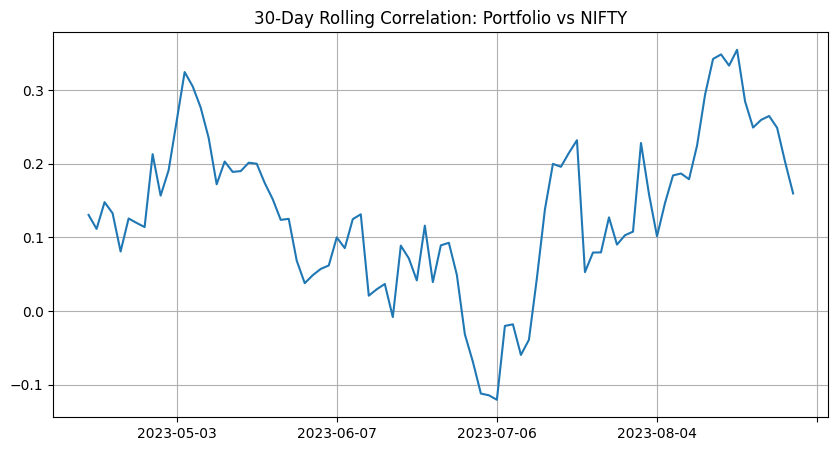

In [16]:
rolling_corr = merged_df['Daily % Profit'].rolling(30).corr(merged_df['NIFTY_Returns'])

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
rolling_corr.plot()
plt.title('30-Day Rolling Correlation: Portfolio vs NIFTY')
plt.grid(True)
plt.show()


Linear Regression: Portfolio Excess vs Nifty Excess
We are performing an Ordinary Least Squares (OLS) regression to analyze the relationship between the portfolio's excess returns and the Nifty's excess returns, using a 5% annual risk-free rate.

Excess Return: The difference between the daily returns of the portfolio and the daily risk-free rate for both the portfolio and the Nifty.

Regression Model: The dependent variable is the portfolio’s excess return, and the independent variable is the Nifty's excess return.

The model is formulated as: 
Portfolio Excess=α+β×Nifty Excess+ϵ

Model Summary: The output includes key statistics like the coefficients, R-squared value, and p-values, which help assess the strength and significance of the relationship.

In [17]:
import statsmodels.api as sm

risk_free_rate = 0.05 / 252
merged_df['Portfolio_Excess'] = merged_df['Daily % Profit'] - risk_free_rate
merged_df['NIFTY_Excess'] = merged_df['NIFTY_Returns'] - risk_free_rate

X = sm.add_constant(merged_df['NIFTY_Excess'])
y = merged_df['Portfolio_Excess']

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:       Portfolio_Excess   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     1.891
Date:                Thu, 08 May 2025   Prob (F-statistic):              0.172
Time:                        10:20:18   Log-Likelihood:                -197.65
No. Observations:                 118   AIC:                             399.3
Df Residuals:                     116   BIC:                             404.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            2.1651      0.123     17.562   

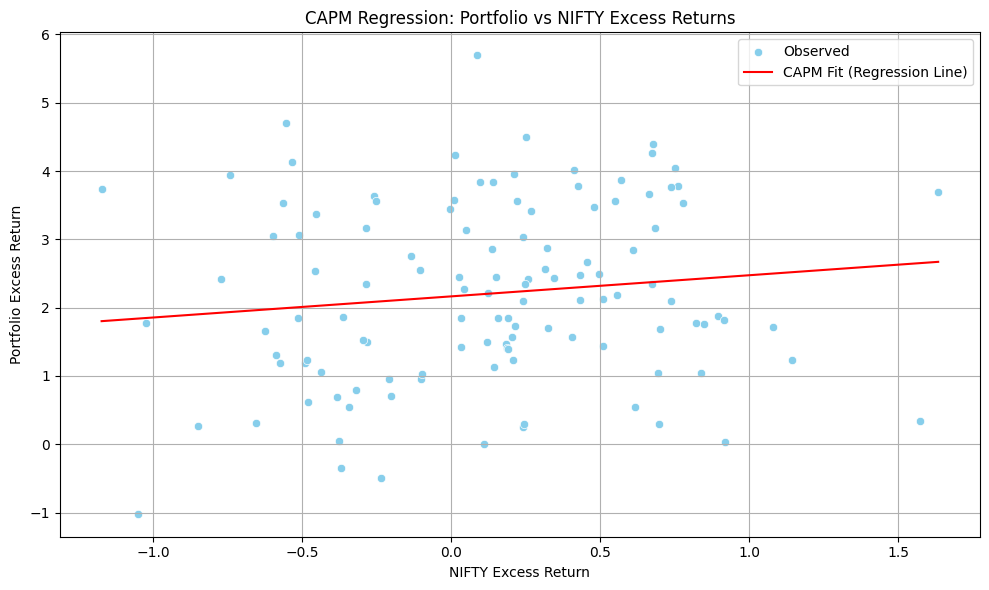

In [18]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.scatterplot(x=merged_df['NIFTY_Excess'], y=merged_df['Portfolio_Excess'], color='skyblue', label='Observed')
predicted = model.predict(X)
sns.lineplot(x=merged_df['NIFTY_Excess'], y=predicted, color='red', label='CAPM Fit (Regression Line)')

plt.title('CAPM Regression: Portfolio vs NIFTY Excess Returns')
plt.xlabel('NIFTY Excess Return')
plt.ylabel('Portfolio Excess Return')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Bootstrap Distribution of Sharpe Ratio
We are using a bootstrap method to estimate the distribution of the Sharpe Ratio by resampling the portfolio’s daily returns with replacement.

Bootstrap Process: A sample of returns is drawn with replacement 1,000 times, each sample having the same size as the original dataset.

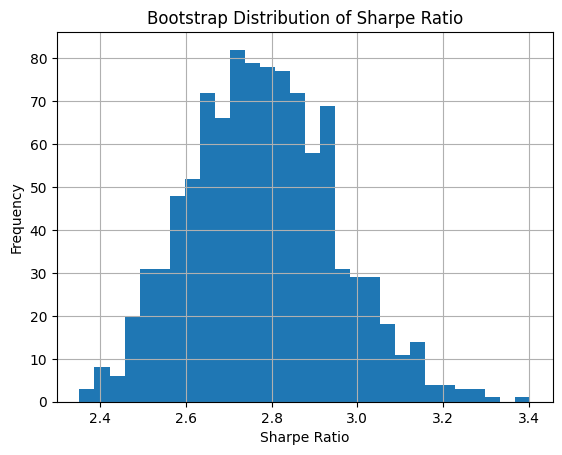

In [19]:
import numpy as np

bootstrap_sharpes = []
returns = vol_df['Daily % Profit'].dropna()
for _ in range(1000):
    sample = np.random.choice(returns, size=len(returns), replace=True)
    sharpe = (sample.mean() - risk_free_rate) / sample.std()
    bootstrap_sharpes.append(sharpe)
plt.hist(bootstrap_sharpes, bins=30)
plt.title("Bootstrap Distribution of Sharpe Ratio")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()
